##### Instructions
- Keep the original structure, you may add additional code cells and/or mark-down cells for clarity, legibility and/or structure.
- Add the required descriptions, explanations, justifications to the mark-down cells. You can find more mark-down tips & tricks online, for example [here](https://jupyter-notebook.readthedocs.io/en/stable/examples/Notebook/Working%20With%20Markdown%20Cells.html) and [here](https://www.ibm.com/docs/en/watson-studio-local/1.2.3?topic=notebooks-markdown-jupyter-cheatsheet)

# EXAM03: Data Science Group Assignment - Iteration 1

**Group name:** Timo & Jakub

**Student names & numbers:**
* Timo Storny - 00099699
* Jakub Holik - 00099393


---

## 0. Iteration setup

**Import libraries**

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

**Load dataset(s)**

In [14]:
df = pd.read_csv("ship_inventory.csv", sep=',')

---

## 1. Business Understanding
*Rubric: LO 6.4D (Reflection on Process)*

**Situation description**

Nebula Brokerage currently prices spaceships using "gut feeling" and rough averages. This is risky, because the inventory prices are highly spread and include extreme outliers, which makes the average inaccurate. Also with this much price variation, it becomes more diffcult to consistently price incoming ships and it may lead to underpricing rare ships (lost profit) or overpricing common ships (low sales and sitting inventory).

**Business objective(s)**

Nebula Brokerage needs a data-driven baseline price that can be used as a standard reference for incoming ships, before building complex AI models. This baseline should:
 - Provide a consistent starting point for pricing decisions.
 - Provide a statistically derived benchmark that will minimize average error

**Data mining goal(s)**

We are going to use naive regression models (mean and median) to determine the best baseline price without knowing anything about the incoming ships. This should minimize the Mean Absolute Error (MAE) and Root Mean Squared Error (EMSE). 

**Success criteria**

We successfully deliver a single baseline reference price for incoming ships that:
- Is derived from the dataset
- Minimizes prediction error without any incoming ship details:
  - Use median as the baseline if optimizing MAE
  - Use mean as the basline if optimizing RMSE
- Includes benchmark performance numbers (MAE and RMSE), so future models can be compared against it

---

## 2. Data Understanding
*Rubric: LO 7.3Q (Visuals) & LO 6.4C (Process)*

**Data exploration**

*Include summary statistics and descriptions of data types below. Describe your findings.*

In [15]:
mean = df['Galactic_Credits'].mean()
median = df['Galactic_Credits'].median()
stdev = df['Galactic_Credits'].std()
mode = df['Galactic_Credits'].mode()[0] # series so take first value only

print(f"Mean: {mean:.2f} \nMedian: {median:.2f} \nStandard deviation: {stdev:.2f} \nMode: {mode}")

## Get total outliers

q1 = df["Galactic_Credits"].quantile(0.25)
q3 = df["Galactic_Credits"].quantile(0.75)
iqr = q3 - q1

outliers_above = df[df["Galactic_Credits"] > q3 + 1.5 * iqr]
outliers_below = df[df["Galactic_Credits"] < q1 - 1.5 * iqr]


print(f"Q1: {q1} \nQ3: {q3} \nInterquartile range: {iqr}")
print(f"Total outlier: {len(outliers_above) + len(outliers_below)}")
df.describe()

Mean: 19453.54 
Median: 15990.00 
Standard deviation: 15540.47 
Mode: 6995
Q1: 7950.0 
Q3: 27990.0 
Interquartile range: 20040.0
Total outlier: 7253


,Ship_ID,Galactic_Credits,Model_Cycle
count,3.688140e+05,368814.000000,361408.000000
mean,7.311485e+09,19453.536818,7511.264529
std,4.381124e+06,15540.472943,9.078571
min,7.301583e+09,501.000000,7400.000000
25%,7.308105e+09,7950.000000,7508.000000
50%,7.312604e+09,15990.000000,7513.000000
75%,7.315245e+09,27990.000000,7517.000000
max,7.317101e+09,777777.000000,7522.000000


## Interpretation
Given that the mean (19453.54) is significantly greater than the median (15990.00), it suggests that the distribution is skewed to the right
Essentially, some very high values are pulling the average upwards. By looking at the mode, we can further confirm this theory as the mode (6995) 
is significantly lower than both the mean and median, sugesting most of data is observed at the lower end, but with many (7253) major outliers (see box-plot). Lastly, the large standard deviation also suggests large variability (a big spread).

**Visualizations and patterns**

*Discover patterns in the data by creating visualizations. Create at least a histogram of Galactic_Credits. Describe your observations.*

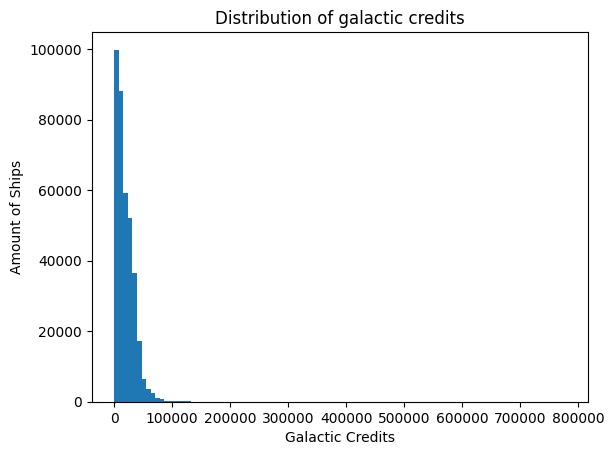

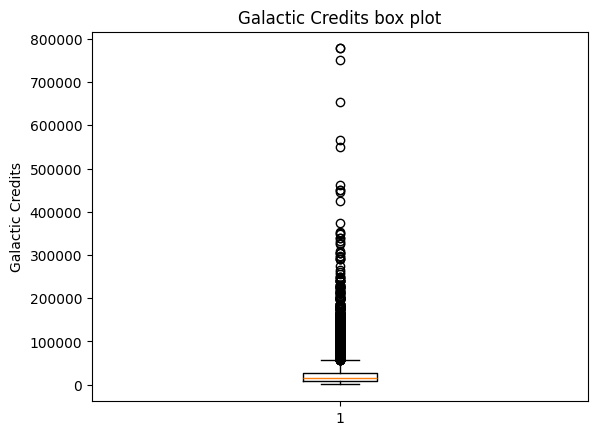

In [16]:
plt.hist(x=df['Galactic_Credits'], bins=100)
plt.title("Distribution of galactic credits")
plt.xlabel("Galactic Credits")
plt.ylabel("Amount of Ships")
plt.show()
plt.boxplot(df['Galactic_Credits'])
plt.title("Galactic Credits box plot")
plt.ylabel("Galactic Credits")
plt.show()

In [17]:
duplicated_rows = df.duplicated().sum()
print(f"Total duplicated rows: {duplicated_rows}")

duplicated_rows_percent = (duplicated_rows / len(df)) * 100 
print(f"Duplicated row percentage: {duplicated_rows_percent:.2f}%")

# checking empty values\
print("------ \n\nEmpty values per columns:")
print(df.isna().sum())

# checking for typos by checking least occuring values
print("------\n")
ship_man_frequency = df["Ship_Manufacturer"].value_counts()
sector_frequency = df["Sector"].value_counts()
print(f"List of bottom 3 least common ship_manufactureres: \n\n{ship_man_frequency.tail(3)} ")
print("------\n")
print(f"List of bottom 3 least common sectors: \n\n{sector_frequency.tail(3)}")


Total duplicated rows: 500
Duplicated row percentage: 0.14%
------ 

Empty values per columns:
Ship_ID                 0
Galactic_Credits        0
Model_Cycle          7406
Ship_Manufacturer       0
Sector                  0
dtype: int64
------

List of bottom 3 least common ship_manufactureres: 

Ship_Manufacturer
Nebula                   589
Nebula Industries (c)    551
Nebula Ind               542
Name: count, dtype: int64 
------

List of bottom 3 least common sectors: 

Sector
Devaron Space       834
Wroona Spaceport    536
Njedha Holy City    352
Name: count, dtype: int64


**Data insights and data quality**
* **Insights:** What are the key trends? What does the distribution look like? What does that mean? 
* **Quality issues:** Document missing values, duplicates, outliers, etc.

**KEY:**
GC -> Galactic Credits

### Data insights

The histogram shows us that the vast majority of the ship prices fall within the 0-100,000 GC, with some major outliers outliers all the way up to 800,000 GC. These outliers shift the mean ship price upwards significantly. Inspecting the box plot, shows us a visualization of the previously calculated 7253 outliers. Majority of them are densely between approximately 80,000 GC and 300,000 GC. 
From a distribution stand-point, the ship prices and heavily positively skewed. 

### Data quality:
#### Duplicates:
Given that that total duplicated rows are 500, or 0.14% of the entire data set, we believe it is fair to assume that these duplicated rows have a neglible impact on the data, that being said we will still drop them in **3. Data Preparation**. 

#### Outliers:
The extreme outliers could be legitimate ships, however they could also represent incorrect measurements/scaling (unit mismatch) or simply data entries errors (human error).

#### Typos:
In order to determine whether there were typos, we determined that instead of manually sifting through 360,000+ entries, we should inspect the categorical columns (Ship_Manufacturer, Sector), and check the least occuring entries. Firstly, this will show us all the unique entries, drastically reducing the amount of entries we need to look through, but also, it will show us typos because they would be at the bottom of the value_counts() list. So, we checked the least 3 occuring entries for both Ship_Manufacturer and Sector, and determined that since the count for the least occuring one is in both cases in the hundreds, that there were no typos present.

#### Missing values:
There were 7406 missing values for *Model_Cycle*, however none for the others. 

---

## 3. Data Preparation
*Rubric: LO 6.4C (Data Science Steps)*

**Cleaning and preprocessing**
*Describe and justify steps taken (e.g., imputation, handling outliers, fixing other errors).*

In [18]:
# Calculcate duplicates:
duplicated_rows = df.duplicated().sum()
duplicated_rows_percent = (duplicated_rows / len(df)) * 100 

print(f"Total duplicated rows: {duplicated_rows}")
print(f"Duplicated row percentage: {duplicated_rows_percent:.2f}%")


# Drop duplicates (500)
df = df.drop_duplicates()

# Drop missing model_cycle rows (7406)
df = df.dropna(subset=["Model_Cycle"])

print(f"Total remaining rows: {len(df)}")

Total duplicated rows: 500
Duplicated row percentage: 0.14%
Total remaining rows: 360916


### Steps we took in cleaning and processing our data

#### Dropping duplicates
Althoguh the duplicates are only 0.14% of the total sample size and will likely have a neglible impact on any metrics, we decided to drop them regardless as they do still have *some* impact nonetheless.

#### Dropping empty values
We have also removed the 7406 rows which had empty values for Model_Cycle. We decided to do this becase it's a very small portion of the dataset and the imputation could have been unreliable.

---

## 4. Modeling
*Rubric: LO 6.4C (Data Science Steps)*

**Model setup**

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
y = df["Galactic_Credits"]

y_train, y_test = train_test_split(y, test_size=0.2, random_state=50)

mean_value = y_train.mean()
median_value = y_train.median()
print(f"Mean benchmark: {mean_value:.2f}")
print(f"Median benchmark: {median_value:.2f} \n")

y_pred_set_mean = [mean_value] * len(y_test)
y_pred_set_median = [median_value] * len(y_test)

# Metrics
mae_mean = mean_absolute_error(y_test, y_pred_set_mean)
mae_median = mean_absolute_error(y_test, y_pred_set_median)

rmse_mean = np.sqrt(mean_squared_error(y_test, y_pred_set_mean))
rmse_median = np.sqrt(mean_squared_error(y_test, y_pred_set_median))

print(f"Mean benchmark model metrics:")
print(f"Mean absolute error: {mae_mean:.2f}")
print(f"Root mean squared error: {rmse_mean:.2f}")

print(f"\nMedian benchmark model metrics:")
print(f"Mean absolute error: {mae_median:.2f}")
print(f"Root mean squared error: {rmse_median:.2f}")

Mean benchmark: 19423.47
Median benchmark: 15990.00 

Mean benchmark model metrics:
Mean absolute error: 11675.73
Root mean squared error: 15862.03

Median benchmark model metrics:
Mean absolute error: 11374.70
Root mean squared error: 16258.06


### Naive regression models (mean & median)  
  To get a simple baseline for predicting Galactic_Credits, we created two constant regression models using only the training part of the target variable:

  - We first split the target into training and test sets, so the baselines are calculated only from the training data and evaluated on unseen test data.
  
  - From the training data we computed:
    - **Mean baseline value**: 19423.47
    - **Median baseline value**: 15990.00
  - These values define two naive models:
    - Mean model: always predicts mean_value for every ship.
    - Median model: always predicts median_value for every ship.  

---

### Testing: what the models predict

**Prediction logic**  
  On the test set, both models only predict a single constant value, either
  - Mean baseline:
    - Every test ship is assigned the same predicted Galactic_Credits equal to the training mean.
  - Median baseline:
    - Every test ship is assigned the same predicted Galactic_Credits equal to the training median.


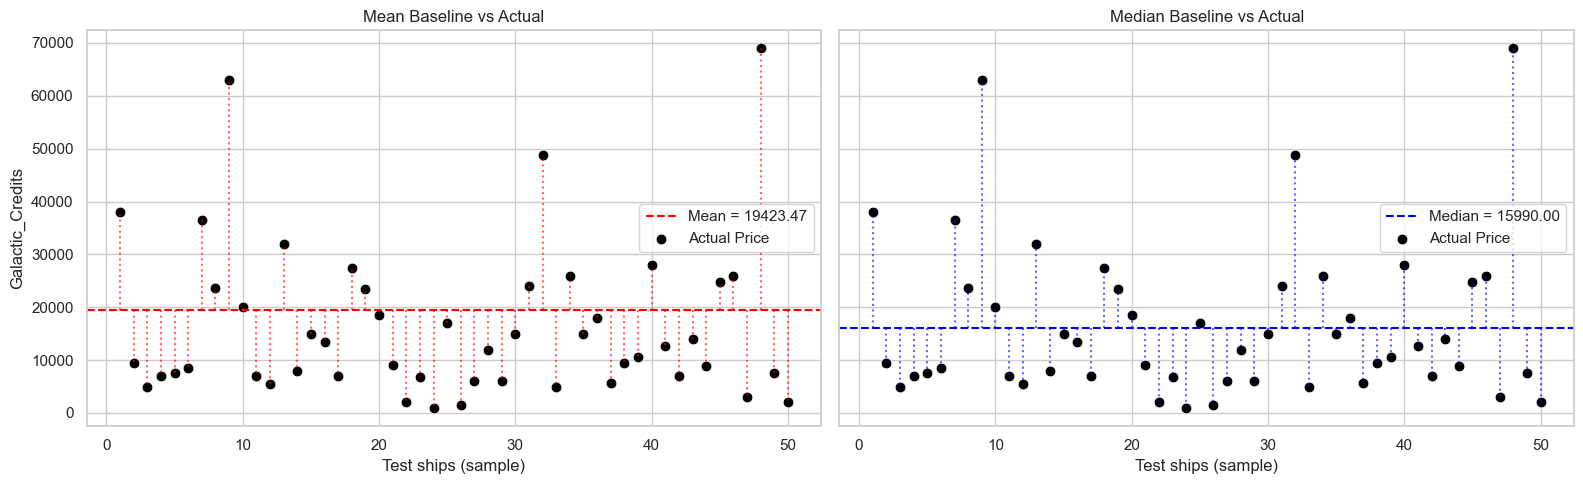

In [24]:
sns.set_theme(style="whitegrid")

actual = y_test.sample(n=50, random_state=1)
x = np.arange(1, len(actual) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), sharey=True)


# mean
ax1.axhline(mean_value, color='red', linestyle="--", label=f"Mean = {mean_value:.2f}")
ax1.vlines(x, ymin=mean_value, ymax=actual, color='red', linestyle=":", alpha=0.6)
sns.scatterplot(x=x, y=actual, s=60, color='black', label='Actual Price', ax=ax1)

ax1.set_xlabel("Test ships (sample)")
ax1.set_ylabel("Galactic_Credits")
ax1.set_title("Mean Baseline vs Actual")
ax1.legend()


# median
ax2.axhline(median_value, color='blue', linestyle="--", label=f"Median = {median_value:.2f}")
ax2.vlines(x, ymin=median_value, ymax=actual, color='blue', linestyle=":", alpha=0.6)
sns.scatterplot(x=x, y=actual, s=60, color='black', label='Actual Price', ax=ax2)

ax2.set_xlabel("Test ships (sample)")
ax2.set_title("Median Baseline vs Actual")
ax2.legend()


plt.tight_layout()
plt.show()

## Visual testing (error plots)  
For both baselines, we visualized their behaviour on a random sample (50 ships) from y_test:

For each baseline, we plotted:
* A horizontal dashed line at the baseline value (mean or median) to show the constant prediction.
* Actual test values as scatter points.
* Vertical dotted lines between the baseline line and each actual value to represent the prediction error for each ship.  
This visualization makes it easy to see that the model always predicts the same value, and the vertical line heights directly show the absolute errors.

---

### Performance metrics: MAE and RMSE

Metrics used
MAE (Mean Absolute Error)   
This tells us the average absolute difference between predicted and actual Galactic_Credits.

RMSE (Root Mean Squared Error)  
RMSE indicates how strongly large errors occur.


#### Clear overview of results

  | Model                    | Baseline value | MAE        | RMSE       |
  |--------------------------|----------------|------------|------------|
  | Mean benchmark model     | 19,463.55      | 11,636.93  | 15,740.88  |
  | Median benchmark model   | 15,990.00      | 11,306.73  | 16,108.79  |

---

### Interpretation of the metrics

Mean vs median baseline
If mae_median and rmse_median are lower than the mean baseline metrics, the median baseline is the better constant predictor, suggesting the target distribution is skewed by outliers.
If mae_mean and rmse_mean are similar to or better than the median baseline, the distribution is likely more symmetric, and both baselines are similarly strong.

Role as benchmark
This model doesn't use any features, therfore it makes it the simplest model for prediction of Galactic_Credits. We will later use this model as a baseline for more robust models.

---

## 5. Evaluation

### Did we meet the Business Understanding goals?

Yes:
Single baseline reference price derived from the dataset:
* Mean baseline value: 19,463.55
* Median baseline value: 15,990.00
Minimizes prediction error without ship details:
* For Mean Absolute Error optimization use median (median MAE is lower).
* For Root Mean Squared Error optimization use mean (mean RMSE is lower).

### Key findings
Link to Data Exploration: These metric results perfectly align with our Data Understanding phase. As seen in our histogram and boxplot, the Galactic_Credits distribution is heavily right-skewed with thousands of extreme outliers.
The Typical Price: Because the mean is artificially pulled upwards by ship outliers, the median proved to be the most robust and accurate baseline for pricing a standard, typical ship.

### Limitations
No Ship Details: A naive model is inherently limited because it ignores all characteristics. It predicts the exact same price for a any ship, meaning it will still be very wrong on the extremes.
Extra Data Needed: To build a truly predictive model, we must utilize existing features (Ship_Manufacturer, Model_Cycle, Sector)

## Personal Contributions

### Jakub Holík (00099393)
#### Contributions
* Wrote the Business Understanding section.
* Worked on the Testing part of the notebook by explaining and visualizing how the mean and median baseline models make constant predictions.
* Wrote the Evaluation section, including the comparison between MAE and RMSE, interpretation of the benchmark results, and linking the final findings back to the business goal.

#### Lessons learned
* I learned that even very simple baseline models are useful, because they give a clear benchmark that future models must outperform.
* I also learned that the choice of evaluation metric matters: the median performed better on MAE, while the mean performed better on RMSE because RMSE is more sensitive to outliers.
* This iteration showed me how important it is to connect technical results back to the business problem instead of only reporting numbers.

### Timo Storny (00099699)
#### Contributions
* Worked on the Data Understanding section.
* Created the histogram and boxplot (Data Understanding)
* Completed the Data Preparation section by checking for duplicates, missing values, and possible typos.
* Developed the Modeling section by setting up the naive regression benchmark models using the mean and median, and calculating their performance metrics.

#### Lessons learned
* I learned that data exploration is essential before modeling, because the skewed distribution and outliers strongly influenced which baseline performed better.
* I also learned that data cleaning decisions should always be justified, even when the issues seem small.
* This iteration helped me better understand how simple regression benchmarks are built and why they are important before moving on to more advanced predictive models.